In [26]:
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import joblib
import  matplotlib.pyplot as plt 

In [27]:
df=pd.read_csv(r"C:\Users\brahi\Desktop\CustomerChurnProject\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [28]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [29]:
df.shape

(7043, 21)

In [30]:
list(df.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [31]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [32]:
# check the descriptive statistics of numeric variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


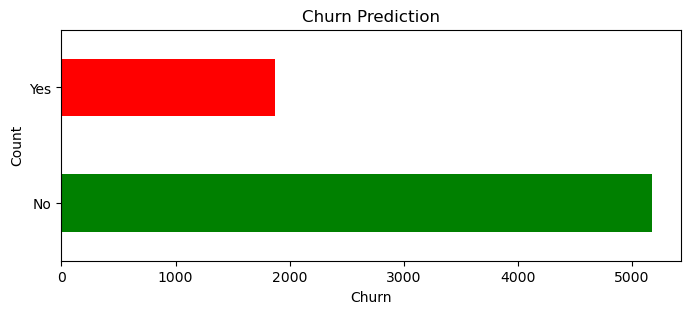

In [33]:
df.Churn.value_counts().plot(kind='barh',color=['green','red'],figsize=(8,3))
plt.title('Churn Prediction')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [34]:
# convert totalCharge feature to numeric
df.TotalCharges=pd.to_numeric(df.TotalCharges,errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [35]:
df.dropna(how='any',inplace=True)

In [36]:
df[df.TotalCharges.isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### We can delete the 11 records in the dataset because : 11/7043 =0.0015 that represent a very small quantities 

In [37]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["1-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)

In [39]:
df=df.drop(["tenure","customerID"],axis=1)

In [40]:
categorical_featues = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
    "tenure_group"
]

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat_featues", OneHotEncoder(handle_unknown="ignore"), categorical_featues)
    ],
    remainder="passthrough"
)

In [51]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTEENN(random_state=42)),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        max_depth=6,
        min_samples_leaf=8,
        random_state=42
    ))
])

In [52]:
X = df.drop('Churn', axis=1)
Y= df['Churn'].map({'Yes': 1, 'No': 0})

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2,random_state=42)

In [54]:
pipeline.fit(X_train, Y_train)

C:\Users\brahi\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_featues',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'tenure_group'])])),
                ('smote', SMOTEENN(random_state=42)),
                ('model',
                 DecisionTreeClassifier(max_depth=6, min_samples_leaf=8,
                                        random_state=42))])

In [55]:
from sklearn.metrics import classification_report
Y_pred = pipeline.predict(X_test)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.75      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.75      1407



###  Improving  the result by using randomForest because it combines MANY trees instead of only one tree.

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
model_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

In [59]:
model_rf.fit(X_train, Y_train)

C:\Users\brahi\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_featues',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'tenure_group'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=12, min_samples_leaf=3,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [60]:
Y_pred_rf = model_rf.predict(X_test)
print(classification_report(Y_test, Y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



#### Decision Tree
Class 0:
precision = 0.89
recall    = 0.74
f1        = 0.81

Class 1:
precision = 0.51
recall    = 0.75
f1        = 0.61

#### Model is catching most minority class (1) → recall = 0.75 
#### But many predictions of class 1 are wrong → precision = 0.51 

#### Random Forest 
Class 0:
precision = 0.83
recall    = 0.91
f1        = 0.87

Class 1:
precision = 0.65
recall    = 0.48
f1        = 0.55

#### Model is very good at class 0 (majority class)
#### But misses many class 1 cases → recall = 0.48 

In [62]:
from joblib import  dump , load

In [63]:
dump(model_rf, "ChurnPrediction.joblib")

['ChurnPrediction.joblib']

In [64]:
model = load("ChurnPrediction.joblib")

In [65]:
model.predict(X_test[:10])

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0], dtype=int64)